<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/33_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

In [11]:
np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)



In [14]:
df = df.sample(40)
df.head(4)

,feature1,feature2,feature3,target
7,1.045371,0.538162,0.812119,1
24,0.748855,2.593111,1.170818,0
18,-0.331617,-1.632386,0.619114,1
36,-1.389866,0.666726,1.343517,0


In [15]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()


In [16]:
# Step 1 - Apply standard scaling

In [19]:
X=df.iloc[:,0:3]
y=df.iloc[:,-1]

In [21]:
scaler=StandardScaler()

In [22]:
X=scaler.fit_transform(X)

In [24]:
# Step 2 - Find Covariance Matrix

In [27]:
covariance_matrix = np.cov(X, rowvar=False)

In [28]:
covariance_matrix

array([[1.02564103, 0.20478114, 0.080118  ],
       [0.20478114, 1.02564103, 0.19838882],
       [0.080118  , 0.19838882, 1.02564103]])

In [29]:
# Step 3 - Finding EV and EVs

In [30]:
eigen_values, eigen_vectors=np.linalg.eig(covariance_matrix)

In [31]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [32]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

Populating the interactive namespace from numpy and matplotlib


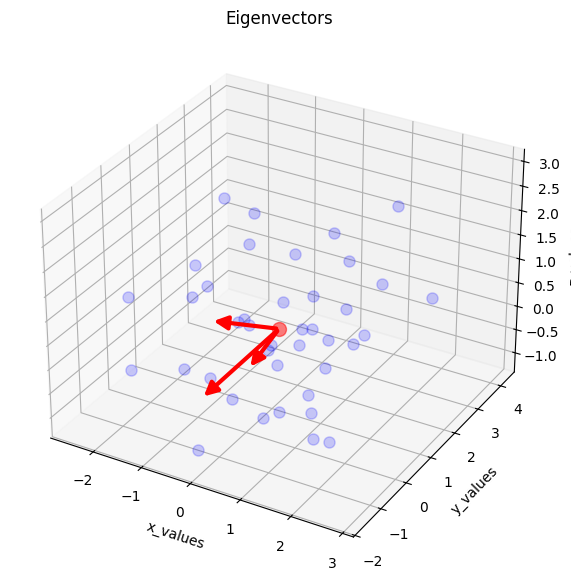

In [37]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        # Access the projection matrix from self.axes.M
        if self.axes:
            xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
            self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
            FancyArrowPatch.draw(self, renderer)
        else:
            # This case should ideally not be hit if the artist is properly added.
            # For robustness, a warning or different handling could be added.
            pass

    # Added do_3d_projection method to handle 3D sorting
    def do_3d_projection(self, renderer=None):
        # Calculate the projected z-coordinates for sorting.
        xs3d, ys3d, zs3d = self._verts3d
        # self.axes will be set by the Figure when the artist is added.
        if self.axes:
            _, _, z_proj = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
            return np.mean(z_proj)
        # Fallback if self.axes is not yet set (though it should be by draw time).
        return np.mean(zs3d)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), v[0]], [df['feature2'].mean(), v[1]], [df['feature3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [38]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [39]:
transformed_df = np.dot(X,pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-0.278732,-0.447581,1
1,-1.348823,-0.536119,0
2,1.726114,0.492511,1
3,1.007007,0.596022,0
4,0.886733,0.522664,1


In [40]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()